#gwen_colab_nongrok.ipynb

<ul>
<li>no ngrok, run localhost in colab cli with agentlab, browsergym, ollama</li>
<li>test vllm server and num joblib with highram cpu</li>
</ul>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# verify cuda, needed if we serve models
import torch

info = {
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "torch_version": torch.__version__,
}

if info["cuda_available"]:
    n = torch.cuda.device_count()
    info["device_count"] = n
    info["devices"] = []
    for i in range(n):
        p = torch.cuda.get_device_properties(i)
        info["devices"].append({
            "id": i,
            "name": p.name,
            "total_memory_gb": round(p.total_memory / (1024**3), 2),
            "sm_count": p.multi_processor_count,
            "capability": f"{p.major}.{p.minor}",
        })

print(info)

{'cuda_available': True, 'cuda_version': '12.8', 'torch_version': '2.10.0+cu128', 'device_count': 1, 'devices': [{'id': 0, 'name': 'Tesla T4', 'total_memory_gb': 14.56, 'sm_count': 40, 'capability': '7.5'}]}


In [ ]:
from google.colab import userdata
import os

ngrok_key = userdata.get("NGROK_AUTH_TOKEN")
hyperbolic_key = userdata.get("HYPERBOLIC_API_KEY")
hf_token = userdata.get("HF_TOKEN")

# tihs is only valid in colab cells, colab cli has to be set separately
os.environ["HYPERBOLIC_API_KEY"] = hyperbolic_key or ""
os.environ["NGROK_AUTH_TOKEN"] = ngrok_key or ""
os.environ["HF_TOKEN"] = hf_token

with open("/content/colab_env.sh", "w") as f:
    f.write(f'export HF_TOKEN="{hf_token}"\n')
    f.write(f'export NGROK_AUTH_TOKEN="{ngrok_key}"\n')
    f.write(f'export HYPERBOLIC_API_KEY="{hyperbolic_key}"\n')

print("Wrote /content/colab_env.sh")
# can you source this from here and it will set the cli env vars?


Wrote /content/colab_env.sh


In [ ]:
!echo "HF_TOKEN in notebook shell: ${HF_TOKEN:+(set)}"
# this doesnt work, it sets HF_TOKEN in colab notebook env but not cli
# run source colab_env.sh from terminal shell

HF_TOKEN in notebook shell: (set)


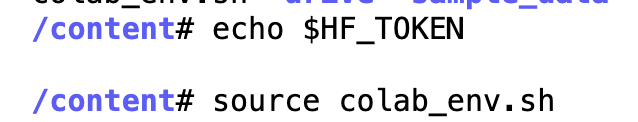

In [ ]:
#install ngrok and ollama client
# ollama server has to be downloaded and has dependencies which have
# to be installed by apt package manager
!pip install -q pyngrok ollama litellm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 27.8 MB/s eta 0:00:00


In [ ]:
# verify .config exists and does NOT contain ngrok
!ls ~/.config

Google	matplotlib  uv


In [ ]:
!ngrok config add-authtoken {os.environ['NGROK_AUTH_TOKEN']}

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
# verify ngrok dir now exists under .config
!ls ~/.config

Google	matplotlib  ngrok  uv


In [ ]:
# create the ngrok.yml fil.e under .config/ngrok
import os
# we only need ngrok.yml if we do ngrok start --all or if
# we specify ngrok.yml to hold the tunnel definitions
# Get the token from the environment variable
# If you are using Colab Secrets, ensure you've set NGROK_AUTH_TOKEN there first!
token = os.environ.get('NGROK_AUTH_TOKEN')

if not token:
    raise ValueError("NGROK_AUTH_TOKEN environment variable not found!")

# Use an f-string (notice the 'f' before the triple quotes)
config = f"""
version: "2"
region: us
authtoken: {token}

tunnels:
  ollama:
    proto: http
    addr: 11434
    host_header: localhost:11434
    domain: labrador-fair-trivially.ngrok-free.app
"""

# Ensure the directory exists
os.makedirs('/root/.config/ngrok', exist_ok=True)

with open('/root/.config/ngrok/ngrok.yml', 'w') as f:
    f.write(config)

print("✅ ngrok.yml updated with environment variable.")

✅ ngrok.yml updated with environment variable.


In [ ]:
#verify ngrok.yml exists under .config/ngrok
!ls ~/.config/ngrok

ngrok.yml


In [ ]:
# copy .ssh over from google drive for git clone
%cp -r /content/drive/MyDrive/'Colab Notebooks'/.ssh /root/
# verify
%ls -al /root
# this copies the .ssh keys to /root for github clone


total 80
drwx------ 1 root root 4096 Mar  6 17:32 ./
drwxr-xr-x 1 root root 4096 Mar  6 17:29 ../
-r-xr-xr-x 1 root root 1071 Jan  1  2000 .bashrc*
drwxr-xr-x 1 root root 4096 Mar  6 17:31 .cache/
drwxr-xr-x 1 root root 4096 Mar  6 17:32 .config/
drwxr-xr-x 5 root root 4096 Mar  5 14:14 .ipython/
drwxr-xr-x 1 root root 4096 Feb  6 14:15 .julia/
drwx------ 1 root root 4096 Mar  5 14:14 .jupyter/
drwxr-xr-x 2 root root 4096 Mar  6 17:29 .keras/
drwx------ 3 root root 4096 Feb  6 14:08 .launchpadlib/
drwxr-xr-x 1 root root 4096 Feb  6 14:15 .local/
drwxr-xr-x 5 root root 4096 Mar  5 14:16 .npm/
drwx------ 3 root root 4096 Mar  6 17:30 .nv/
-rw-r--r-- 1 root root  161 Jul  9  2019 .profile
drwx------ 2 root root 4096 Mar  6 17:32 .ssh/
-r-xr-xr-x 1 root root  254 Jan  1  2000 .tmux.conf*
-rw-r--r-- 1 root root  211 Mar  5 14:15 .wget-hsts


In [ ]:
#verify ssh keys are there
!ls /root/.ssh

id_rsa	id_rsa.pub


In [ ]:
# copy models from /drive/MyDrive/'Colab Notebooks'/.cache/huggingface to /root/.cache
#gigs will take a while
%cp -r /content/drive/MyDrive/'Colab Notebooks'/.cache/huggingface /root/.cache/
%ls -al /root/.cache/huggingface/hub

total 16
drwx------ 4 root root 4096 Mar  6 17:33 ./
drwx------ 4 root root 4096 Mar  6 17:33 ../
drwx------ 3 root root 4096 Mar  6 17:33 .locks/
drwx------ 6 root root 4096 Mar  6 17:33 models--deepseek-ai--DeepSeek-R1-Distill-Qwen-1.5B/


In [ ]:
# copy ollama models from 'Colab Notebooks'
# copy the ollama models to /root 6GB
%cp -r /content/drive/MyDrive/'Colab Notebooks'/.ollama /root/

In [ ]:
# install ollama server install zstd for running ollama server
%%bash
set -e

apt-get install zstd
# Install ollama server. This is not the client which was installed with pip installed ollama
curl -fsSL https://ollama.com/install.sh | sh



Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 37 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (565 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [ ]:
!# Show version should fail bc ollama not started yet. This verifies
# there arent other servers running
!ollama --version

In [ ]:
import subprocess, time, shutil, socket, os

def port_open(host="127.0.0.1", port=11434) -> bool:
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.settimeout(0.2)
        return s.connect_ex((host, port)) == 0

print("Starting Ollama server...")

# 1) Ensure ollama exists
ollama_path = shutil.which("ollama")
if not ollama_path:
    raise RuntimeError("ollama binary not found. Install Ollama first (install.sh) or ensure it's on PATH.")

# 2) If already running, don't start another copy
if port_open():
    print("✅ Ollama already listening on 127.0.0.1:11434 (server already running).")
else:
    log_path = "/tmp/ollama.log"
    log = open(log_path, "a", buffering=1)
    # tail /tmp/ollama.log to see progress of request
    p = subprocess.Popen(
        [ollama_path, "serve"],
        stdout=log,
        stderr=log,
        start_new_session=True,
    )

    time.sleep(1)

    if p.poll() is None:
        print("✅ Started Ollama. PID:", p.pid)
    else:
        print("❌ Ollama exited immediately. Return code:", p.returncode)
        log.close()
        # show last log lines
        try:
            with open(log_path, "r") as f:
                tail = f.readlines()[-80:]
            print("---- /tmp/ollama.log (tail) ----")
            print("".join(tail))
        except Exception as e:
            print("Could not read log:", e)

# Optional: quick health check
print("Port 11434 open:", port_open())

Starting Ollama server...
✅ Started Ollama. PID: 2894
Port 11434 open: True


**Look at /tmp/ollama.log to verify**

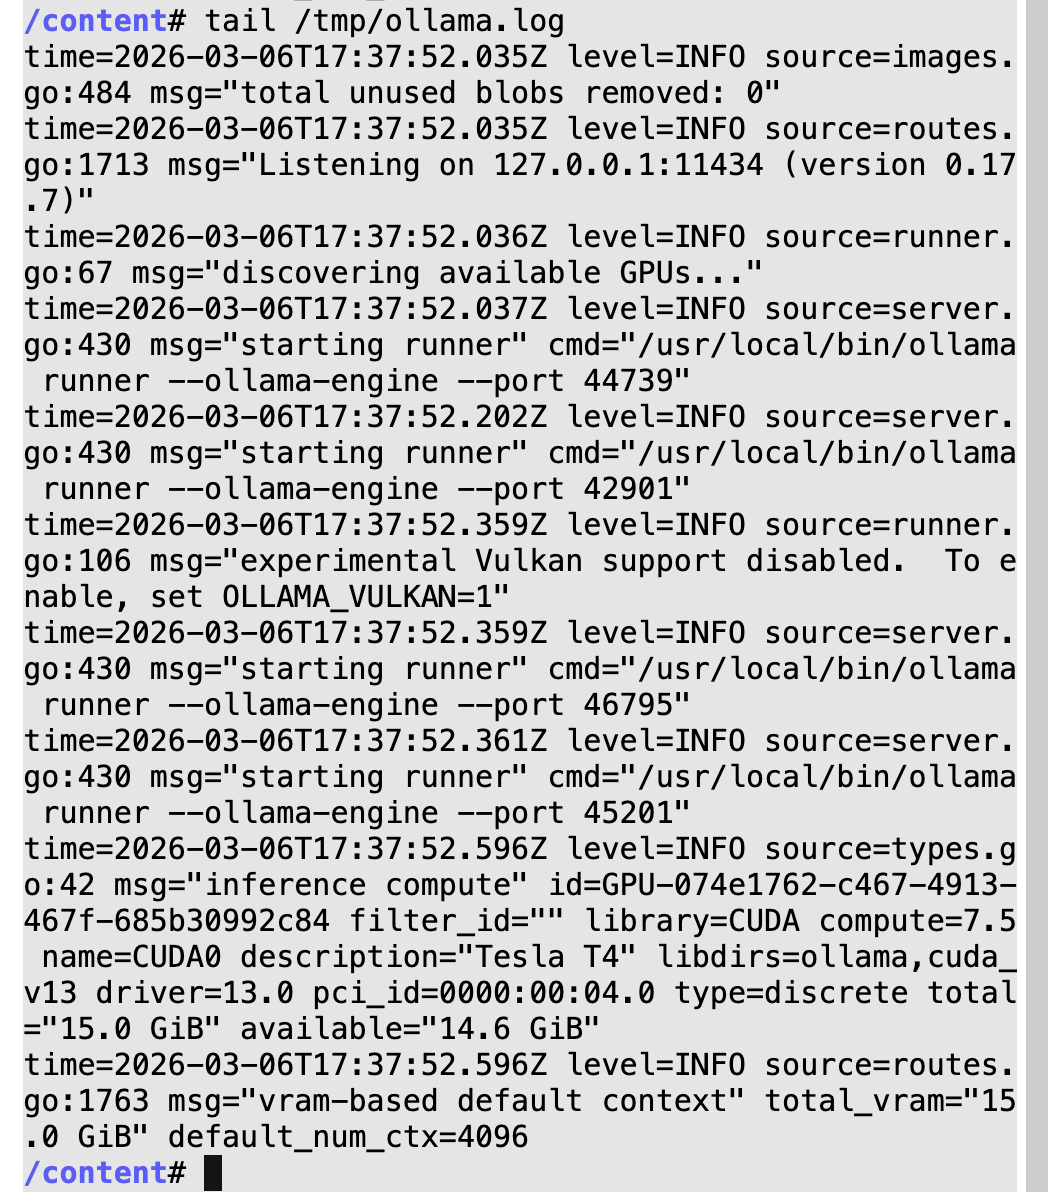

In [ ]:
# Wait for server
# Pull model (downloads if missing)
!ollama pull qwen3-vl
# this was copied over from 'Colab Notebooks' should be fast

In [ ]:
# test we can query model
%%bash
set -euo pipefail

apt-get -qq update >/dev/null
apt-get -qq install -y jq >/dev/null


curl -sS http://127.0.0.1:11434/api/chat \
  -H "Content-Type: application/json" \
  -d '{
    "model": "qwen3-vl",
    "messages": [{"role":"user","content":"Give me a 2-sentence summary of PPO."}],
    "stream": true
  }' | jq -r '(.message.content // .message.thinking // "")'











































































































































































































































































































































P
PO
 (
Pro
x
imal
 Policy
 Optimization
)
 is
 a
 reinforcement
 learning
 algorithm
 designed
 to
 train
 agents
 by
 optimizing
 policies
 in
 a
 stable
 and
 sample
-efficient
 manner
.
 It
 achieves
 this
 by
 using
 a
 clipping
 mechanism
 within
 a
 trust
 region
 to
 limit
 how
 much
 the
 new
 policy
 can
 dev
iate
 from
 the
 old
 one
 during
 each
 update
 step
,
 preventing
 large
,
 destabil
izing
 changes
.



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


**Verify we can see teh request in /tmp/ollama.log

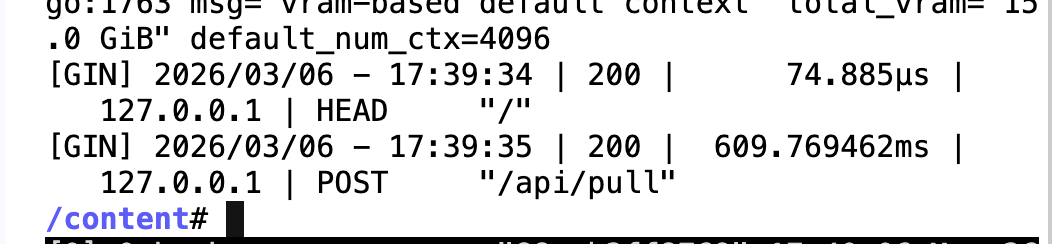

In [ ]:
# verify ollama server responds to cli model requests
!ollama list

NAME               ID              SIZE      MODIFIED      
qwen3-vl:latest    901cae732162    6.1 GB    4 minutes ago    


In [ ]:
# test ollama server pid and port
!ss -ltnp | grep 11434 || true
!ps -ef | grep -i '[o]llama'

LISTEN 0      4096       127.0.0.1:11434      0.0.0.0:*    users:(("ollama",pid=2894,fd=3))       
root        2894     343  0 17:37 ?        00:00:00 /usr/local/bin/ollama serve
root        4352    2894 87 17:40 ?        00:02:53 /usr/local/bin/ollama runner --ollama-engine --model /root/.ollama/models/blobs/sha256-ed12a4674d727a74ac4816c906094ea9d3119fbea46ca93288c3ce4ffbe38c55 --port 35803


In [ ]:
# verify ollama server is serving requests
!curl -s http://127.0.0.1:11434/api/tags | head

{"models":[{"name":"qwen3-vl:latest","model":"qwen3-vl:latest","modified_at":"2026-03-06T17:39:35.440162681Z","size":6140415879,"digest":"901cae73216286ea8c5aba8b46d307ff7188f737285ec500c795a12f05225d28","details":{"parent_model":"","format":"gguf","family":"qwen3vl","families":["qwen3vl"],"parameter_size":"8.8B","quantization_level":"Q4_K_M"}}]}

In [ ]:
# Kill old ngrok
# 2 ways to start ngrok
# 1) the grok start all command which starts all the tunnels in ngrok.yml
# 2) ngrok start ollama. Ollama is the name of a specific tunnel in ngrok.yml
#
!pkill -f ngrok || true

# Start ngrok in background with explicit tunnel named ollama in ngrok.yml
!nohup ngrok start ollama \
    --config=/root/.config/ngrok/ngrok.yml \
    --log=stdout \
    --log-level=info \
    > /tmp/ngrok.log 2>&1 &

# Give it time to start
!sleep 5

# Verify ngrok process
!ps -ef | grep -i '[n]grok'

# Verify inspect API
!curl -s http://127.0.0.1:4040/api/tunnels | python3 -m json.tool



^C
root        5270       1  7 17:43 ?        00:00:00 /usr/bin/python3 /usr/local/bin/ngrok start ollama --config=/root/.config/ngrok/ngrok.yml --log=stdout --log-level=info
root        5280    5270  6 17:43 ?        00:00:00 /root/.config/ngrok/ngrok start ollama --config=/root/.config/ngrok/ngrok.yml --log=stdout --log-level=info
{
    "tunnels": [
        {
            "name": "ollama",
            "ID": "3088c143fc7076c2ec5ac6430370e276",
            "uri": "/api/tunnels/ollama",
            "public_url": "https://labrador-fair-trivially.ngrok-free.app",
            "proto": "https",
            "config": {
                "addr": "http://localhost:11434",
                "inspect": true
            },
            "metrics": {
                "conns": {
                    "count": 0,
                    "gauge": 0,
                    "rate1": 0,
                    "rate5": 0,
                    "rate15": 0,
                    "p50": 0,
                    "p90": 0,
          

In [ ]:
# If still nothing, print logs
!tail -n 50 /tmp/ngrok.log

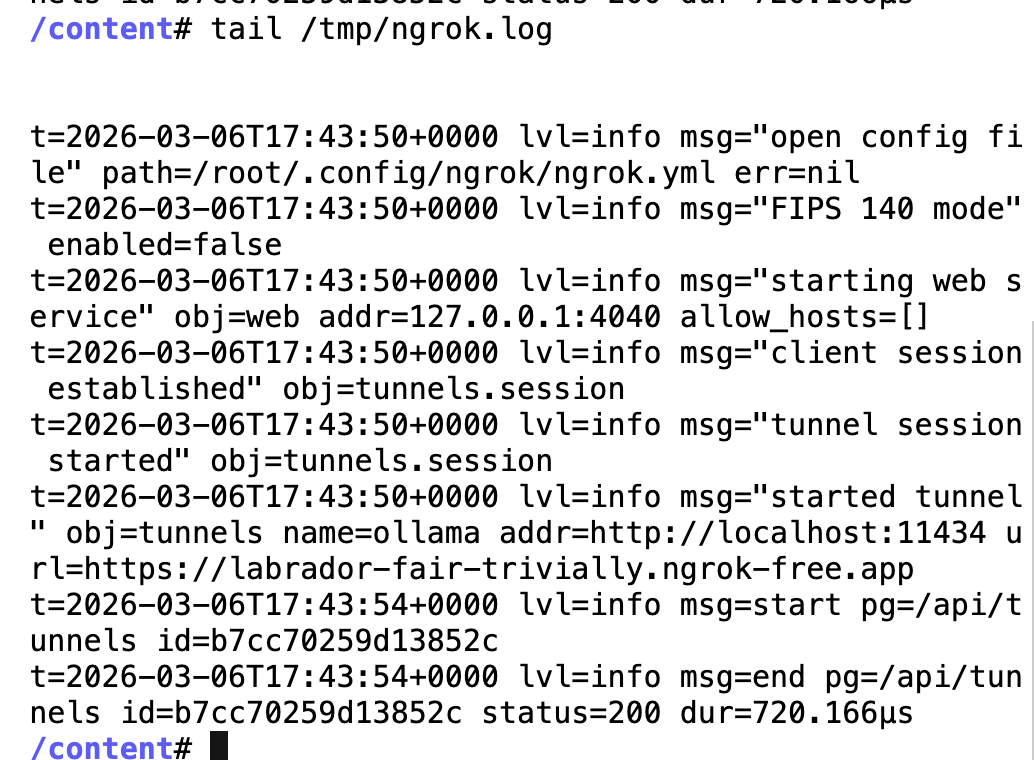

** replace the localhost address with the ngrok address and verify the response matches the localhost**

**RUN THIS IN MAC TERMINAL WINDOW NOT IN COLAB**

```
curl -sS https://labrador-fair-trivially.ngrok-free.app/api/chat \
  -H "Content-Type: application/json" \
  -d '{
    "model": "qwen3-vl",
    "messages": [{"role":"user","content":"Give me a 2-sentence summary of PPO."}],
    "stream": true
  }' | jq -r '(.message.content // .message.thinking // "")'
```

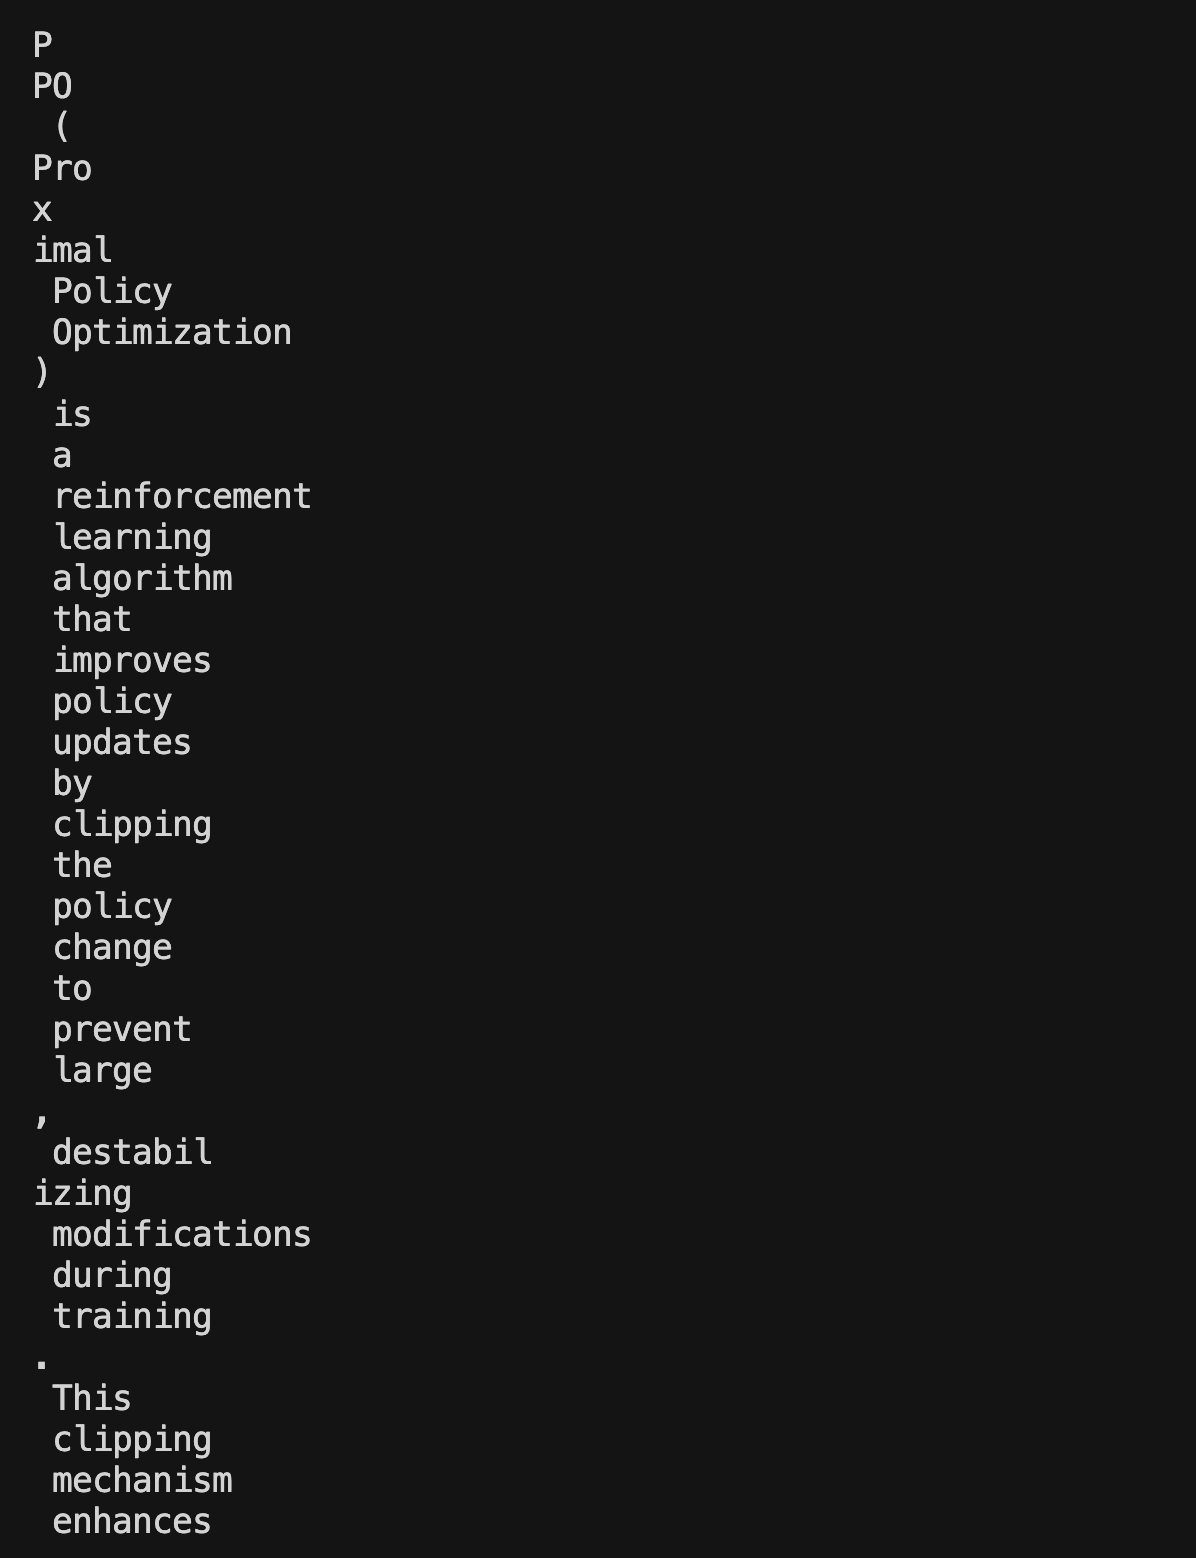

In [ ]:
# instalnstall teh repos to run locally

In [ ]:
!git clone https://github.com/dougc333/BrowserGym

Cloning into 'BrowserGym'...
remote: Enumerating objects: 6600, done.
remote: Counting objects: 100% (2257/2257), done.
remote: Compressing objects: 100% (973/973), done.
remote: Total 6600 (delta 1357), reused 2053 (delta 1219), pack-reused 4343 (from 3)
Receiving objects: 100% (6600/6600), 35.06 MiB | 15.02 MiB/s, done.
Resolving deltas: 100% (3457/3457), done.


In [ ]:
!git clone https://github.com/dougc333/AgentLab

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
fatal: could not create work tree dir 'AgentLab': No such file or directory



**RUN THIS IN COLAB CLI**
```
export MINIWOB_URL="http://localhost:8000/miniwob/"
```


In [ ]:
# the make file has to be modified to use port 8000 the original repo used 8080
# port 8080 used by colab

In [ ]:
%cd /content/AgentLab
!pip install -e .
#!make setup
# we dont need this anymore, miniwob-plusplus is downloaded and checked into git
# starting the server is blocking
#!make miniwob

/content/AgentLab
Obtaining file:///content/AgentLab
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.8/324.8 kB 19.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of litellm to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of litellm to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versi

In [ ]:
import subprocess, time, socket, os, signal

def start_miniwob(port=8000, root="/content/AgentLab/miniwob-plusplus/miniwob/html"):
    log = open("/content/miniwob_http.log", "a", buffering=1)
    p = subprocess.Popen(
        ["python3", "-m", "http.server", str(port), "--bind", "127.0.0.1", "--directory", root],
        stdout=log, stderr=log, start_new_session=True
    )
    time.sleep(1)
    return p.pid

pid = start_miniwob()
print("MiniWoB PID:", pid)

MiniWoB PID: 8165


In [ ]:
os.killpg(pid, signal.SIGKILL)

In [ ]:
!curl -sS -I http://127.0.0.1:8000/miniwob/ | head -n 5
!curl -sS -I http://127.0.0.1:8000/miniwob/click-checkboxes-soft.html | head -n 5

HTTP/1.0 200 OK
Server: SimpleHTTP/0.6 Python/3.12.12
Date: Fri, 06 Mar 2026 05:12:12 GMT
Content-type: text/html; charset=utf-8
Content-Length: 8389
HTTP/1.0 200 OK
Server: SimpleHTTP/0.6 Python/3.12.12
Date: Fri, 06 Mar 2026 05:12:13 GMT
Content-type: text/html
Content-Length: 4027


In [ ]:
!ss -ltnp | grep ':8000' || true

LISTEN 0      5          127.0.0.1:8000       0.0.0.0:*    users:(("python3",pid=8165,fd=3))      


In [ ]:
#install playwright and deps
!pip install litellm

!playwright install
!apt-get install libatk1.0-0 libatk-bridge2.0-0 libatspi2.0-0 libxcomposite1 libgtk-3-0
"""
libwoff2dec.so.1.0.2
libgstallocators-1.0.so.0
libgstapp-1.0.so.0
libgstpbutils-1.0.so.0
libgstaudio-1.0.so.0
libgsttag-1.0.so.0
libgstvideo-1.0.so.0
libgstgl-1.0.so.0
libgstcodecparsers-1.0.so.0
libgstfft-1.0.so.0
libharfbuzz-icu.so.0
libenchant-2.so.2
libsecret-1.so.0
libhyphen.so.0
libmanette-0.2.so.0
"""
!apt-get update -qq
!apt-get install -y \
  libwoff2dec1 \
  libgstreamer1.0-0 \
  gstreamer1.0-plugins-base \
  gstreamer1.0-plugins-good \
  libgstreamer-gl1.0-0 \
  libharfbuzz-icu0 \
  libenchant-2-2 \
  libsecret-1-0 \
  libhyphen0 \
  libmanette-0.2-0

Playwright Host validation warning: 
╔══════════════════════════════════════════════════════╗
║ Host system is missing dependencies to run browsers. ║
║ Missing libraries:                                   ║
║     libwoff2dec.so.1.0.2                             ║
║     libgstallocators-1.0.so.0                        ║
║     libgstapp-1.0.so.0                               ║
║     libgstpbutils-1.0.so.0                           ║
║     libgstaudio-1.0.so.0                             ║
║     libgsttag-1.0.so.0                               ║
║     libgstvideo-1.0.so.0                             ║
║     libgstgl-1.0.so.0                                ║
║     libgstcodecparsers-1.0.so.0                      ║
║     libgstfft-1.0.so.0                               ║
║     libharfbuzz-icu.so.0                             ║
║     libenchant-2.so.2                                ║
║     libsecret-1.so.0                                 ║
║     libhyphen.so.0                               

#verify HF_TOKEN not "". It needs to be set if we are using HF APIs.
#NOTE: we have migrated off these
```
echo $HF_TOKEN
```

#make sure in agentlab;
```
cd /content/AgentLab
pip install -e .
```
#playwright install
```
playwright install
```

#apt-get install libatk1.0-0 libatk-bridge2.0-0 libatspi2.0-0 libxcomposite1
```
apt-get install libatk1.0-0 libatk-bridge2.0-0 libatspi2.0-0 libxcomposite1

```
#have to run in cli s
!python tutorials/2_eval_on_miniwob/ollama.py

Visualizing /root/agentlab_results

In [ ]:
import os
from IPython.display import Image, display

# Find the latest experiment folder
results_dir = "/root/agentlab_results/"
latest_study = sorted([d for d in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir, d))])[-1]
print(f"latest_study:{latest_study}")
study_path = os.path.join(results_dir, latest_study)
print(f"study_path:{study_path}")
# Find the first task folder inside that study
task_folders = [d for d in os.listdir(study_path) if os.path.isdir(os.path.join(study_path, d))]
if task_folders:
    print(f"task_folders:{task_folders}")
    task_path = os.path.join(study_path, task_folders[0], "step_001") # Check step 1
    screenshot_path = os.path.join(task_path, "last_action_location_screenshot.png")

    if os.path.exists(screenshot_path):
        print(f"Showing click for: {task_folders[0]}")
        display(Image(filename=screenshot_path))
    else:
        print("No screenshot found for this step. The agent might have errored before clicking.")

import json
import pandas as pd

results_summary = []

for folder in task_folders:
    task_path = os.path.join(study_path, folder)
    # MiniWoB logs usually store terminal status in a summary or scores file
    score_file = os.path.join(task_path, "scores.json")

    status = "Unknown"
    score = 0

    if os.path.exists(score_file):
        with open(score_file, 'r') as f:
            data = json.load(f)
            score = data.get("score", 0)
            status = "Success" if score > 0 else "Failure"
    else:
        # Check if the folder exists but has no steps (Crash)
        steps = [d for d in os.listdir(task_path) if d.startswith("step_")]
        status = "Crashed/No Steps" if not steps else "Incomplete"

    results_summary.append({
        "Task": folder.split('.')[-1], # e.g., click-dialog_28
        "Status": status,
        "Score": score
    })

df = pd.DataFrame(results_summary)
print(df)
print(f"\nOverall Success Rate: {df[df['Status'] == 'Success'].shape[0] / len(df) * 100:.2f}%")

latest_study:2026-03-05_09-42-26_genericagent-ollama-qwen3-vl-latest-on-miniwob-tiny-test
study_path:/root/agentlab_results/2026-03-05_09-42-26_genericagent-ollama-qwen3-vl-latest-on-miniwob-tiny-test
task_folders:['2026-03-05_09-42-26_GenericAgent-ollama_qwen3-vl_latest_on_miniwob.click-checkboxes_20', '2026-03-05_09-42-26_GenericAgent-ollama_qwen3-vl_latest_on_miniwob.click-checkboxes_7', '2026-03-05_09-42-26_GenericAgent-ollama_qwen3-vl_latest_on_miniwob.click-dialog_28', '2026-03-05_09-42-26_GenericAgent-ollama_qwen3-vl_latest_on_miniwob.click-dialog_14']
No screenshot found for this step. The agent might have errored before clicking.
                  Task      Status  Score
0  click-checkboxes_20  Incomplete      0
1   click-checkboxes_7  Incomplete      0
2      click-dialog_28  Incomplete      0
3      click-dialog_14  Incomplete      0

Overall Success Rate: 0.00%
